In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping

import joblib
print("TensorFlow Version:", tf.__version__)


TensorFlow Version: 2.21.0


In [2]:
# Load data
df = pd.read_csv("CRDB.csv")
print(df.head())

         Date  Open  High   Low  Close  Adj Close  Volume
0  2016-01-04  2700  2717  2692   2710       2710  611107
1  2016-01-05  2710  2731  2678   2705       2705  342929
2  2016-01-06  2720  2743  2680   2710       2710  491651
3  2016-01-07  2710  2719  2687   2695       2695  325889
4  2016-01-08  2685  2717  2662   2690       2690  366388


In [3]:
# CLEAN COLUMN NAMES
# =====================================================

df.columns = df.columns.str.strip()

print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [4]:
# CONVERT DATE
# =====================================================

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    df = df.reset_index(drop=True)


In [5]:
# REMOVE MISSING VALUES
# =====================================================

df = df.dropna()

# =====================================================
# REMOVE DUPLICATES
# =====================================================

df = df.drop_duplicates()

In [6]:
# NUMERIC COLUMNS
# =====================================================

price_columns = ["Open", "High", "Low", "Close", "Volume"]

for col in price_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

In [7]:
# FEATURE ENGINEERING
# =====================================================

# Daily Return
df["Return"] = df["Close"].pct_change()

# 10-day Moving Average
df["MA10"] = df["Close"].rolling(10).mean()

# 20-day Moving Average
df["MA20"] = df["Close"].rolling(20).mean()

# 50-day Moving Average
df["MA50"] = df["Close"].rolling(50).mean()

# Volatility
df["Volatility"] = df["Return"].rolling(10).std()

# Momentum
df["Momentum"] = df["Close"] - df["Close"].shift(10)


In [8]:
# RSI
# =====================================================

delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))



In [9]:
# MACD
# =====================================================

ema12 = df["Close"].ewm(span=12).mean()
ema26 = df["Close"].ewm(span=26).mean()

df["MACD"] = ema12 - ema26
df["Signal"] = df["MACD"].ewm(span=9).mean()


In [11]:
# FINAL CLEAN
# =====================================================

df = df.dropna()

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nPreview:")
print(df.tail())


Dataset Shape: (2691, 16)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return',
       'MA10', 'MA20', 'MA50', 'Volatility', 'Momentum', 'RSI', 'MACD',
       'Signal'],
      dtype='object')

Missing Values:
Date          0
Open          0
High          0
Low           0
Close         0
Adj Close     0
Volume        0
Return        0
MA10          0
MA20          0
MA50          0
Volatility    0
Momentum      0
RSI           0
MACD          0
Signal        0
dtype: int64

Preview:
           Date  Open  High   Low  Close  Adj Close  Volume    Return    MA10  \
2735 2026-06-29  2755  2772  2744   2760       2760  260539  0.005464  2750.5   
2736 2026-06-30  2775  2793  2767   2775       2775  236470  0.005435  2753.0   
2737 2026-07-01  2775  2804  2753   2765       2765  310353 -0.003604  2754.0   
2738 2026-07-02  2795  2823  2783   2795       2795  607115  0.010850  2758.5   
2739 2026-07-03  2805  2824  2766   2790       2790  346714 -0.001789 

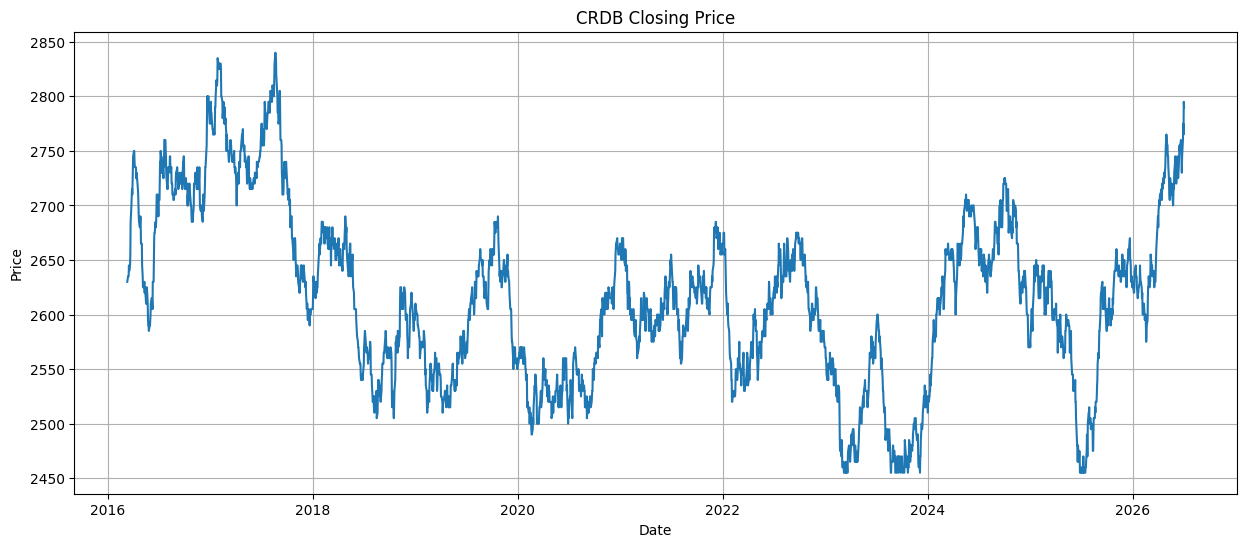

In [12]:
 #PLOT CLOSE PRICE
# =====================================================

plt.figure(figsize=(15,6))
plt.plot(df["Date"], df["Close"])
plt.title("CRDB Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [13]:
# PART 2 - FEATURE SELECTION + SCALING + SEQUENCES
# =====================================================

# Features zinazotumika kufundisha model
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "MA10",
    "MA20",
    "MA50",
    "Volatility",
    "Momentum",
    "RSI",
    "MACD",
    "Signal"
]

features = df[feature_columns]

print("Features Shape:", features.shape)


Features Shape: (2691, 14)


In [14]:
# SCALE FEATURES
# =====================================================

scaler = MinMaxScaler(feature_range=(0, 1))

scaled = scaler.fit_transform(features)

print("Scaled Shape:", scaled.shape)

# Save scaler
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")

print("✅ Scaler Saved")


Scaled Shape: (2691, 14)
✅ Scaler Saved


In [15]:
# CREATE LSTM SEQUENCES
# =====================================================

SEQ_LENGTH = 60

def create_sequences(data, seq_length=60):

    X = []
    y = []

    close_index = feature_columns.index("Close")

    for i in range(seq_length, len(data)):

        X.append(data[i-seq_length:i])

        # Target = Close Price ya siku inayofuata
        y.append(data[i, close_index])

    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LENGTH)

print("X Shape :", X.shape)
print("y Shape :", y.shape)


X Shape : (2631, 60, 14)
y Shape : (2631,)


In [16]:
# TRAIN / TEST SPLIT
# =====================================================

split_index = int(len(X) * 0.80)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("\n==============================")
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))
print("==============================")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)




Training Samples : 2104
Testing Samples  : 527
X_train: (2104, 60, 14)
X_test : (527, 60, 14)
y_train: (2104,)
y_test : (527,)


In [17]:
# CHECK DATA
# =====================================================

print("\nLast Training Close (Scaled):", y_train[-1])
print("First Testing Close (Scaled):", y_test[0])

print("\n✅ PART 2 COMPLETED SUCCESSFULLY")


Last Training Close (Scaled): 0.558441558441559
First Testing Close (Scaled): 0.5714285714285721

✅ PART 2 COMPLETED SUCCESSFULLY


In [18]:
# PART 3 - BUILD & TRAIN LSTM MODEL
# =====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [19]:
# BUILD MODEL
# =====================================================

model = Sequential([

    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        128,
        return_sequences=True
    ),
    Dropout(0.30),

    LSTM(
        64,
        return_sequences=True
    ),
    Dropout(0.30),

    LSTM(32),
    Dropout(0.20),

    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)

])


In [20]:
# COMPILE MODEL
# =====================================================

model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        73,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,641 (533.75 KB)

 Trainable params: 136,641 (533.75 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# CALLBACKS
# =====================================================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "models/stock_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


In [22]:
# TRAIN MODEL
# =====================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1

)

print("\n✅ TRAINING COMPLETED")


Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0644 - mae: 0.1883
Epoch 1: val_loss improved from None to 0.00393, saving model to models/stock_model.keras

Epoch 1: finished saving model to models/stock_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 296ms/step - loss: 0.0295 - mae: 0.1198 - val_loss: 0.0039 - val_mae: 0.0505
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.0061 - mae: 0.0609
Epoch 2: val_loss did not improve from 0.00393
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 308ms/step - loss: 0.0060 - mae: 0.0604 - val_loss: 0.0100 - val_mae: 0.0858
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.0049 - mae: 0.0535
Epoch 3: val_loss improved from 0.00393 to 0.00345, saving model to models/stock_model.keras

Epoch 3: finished saving model to models/stock_model.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 16s 238ms/step - loss: 0.0046 - mae: 0.0521 - val_loss: 0.0035 - val_mae: 0.0471
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - loss: 0.0043 - mae: 0.050

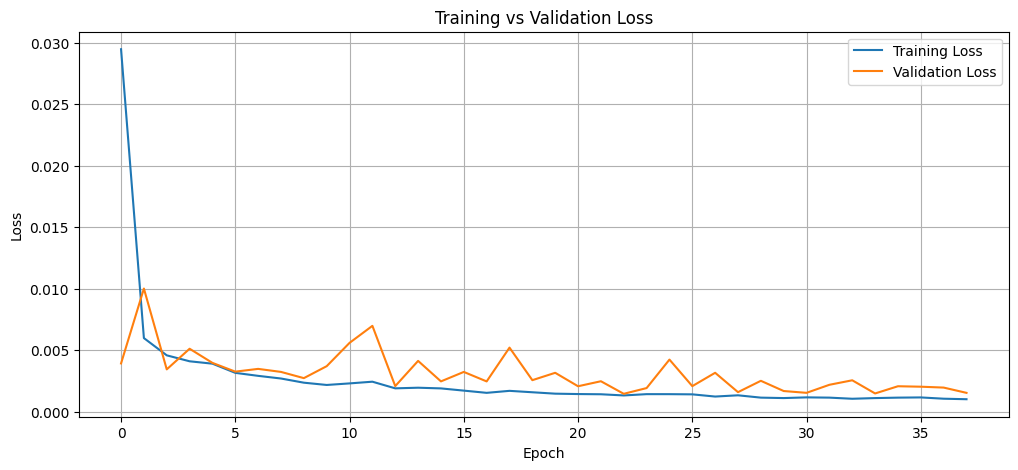

In [23]:
# PLOT TRAINING LOSS
# =====================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# PART 4 - EVALUATION & FUTURE PREDICTIONS
# =====================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================
# PREDICT TEST DATA
# =====================================================

y_pred = model.predict(X_test)


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step


In [25]:
# INVERSE SCALING
# =====================================================

close_index = feature_columns.index("Close")

def inverse_close(values):
    temp = np.zeros((len(values), len(feature_columns)))
    temp[:, close_index] = values.reshape(-1)
    return scaler.inverse_transform(temp)[:, close_index]

y_test_inv = inverse_close(y_test)
y_pred_inv = inverse_close(y_pred.reshape(-1))

In [26]:
# MODEL EVALUATION
# =====================================================

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_inv, y_pred_inv)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


MODEL PERFORMANCE
MSE  : 217.3862
MAE  : 11.6943
RMSE : 14.7440
R²   : 0.9546


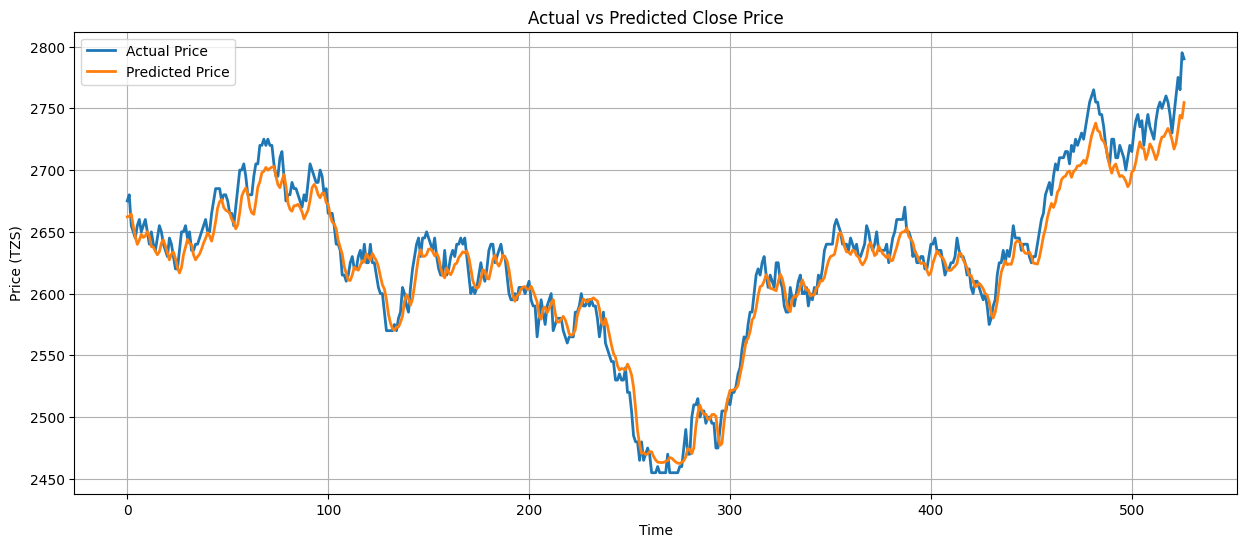

In [27]:
# ACTUAL VS PREDICTED
# =====================================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test_inv,
    label="Actual Price",
    linewidth=2
)

plt.plot(
    y_pred_inv,
    label="Predicted Price",
    linewidth=2
)

plt.title("Actual vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Price (TZS)")
plt.legend()
plt.grid(True)
plt.show()




CRDB PRICE FORECAST
Today's Close       : 2790.00 TZS
Tomorrow Prediction : 2756.62 TZS
Next Week Prediction: 2746.98 TZS
Next Month Forecast : 2751.37 TZS


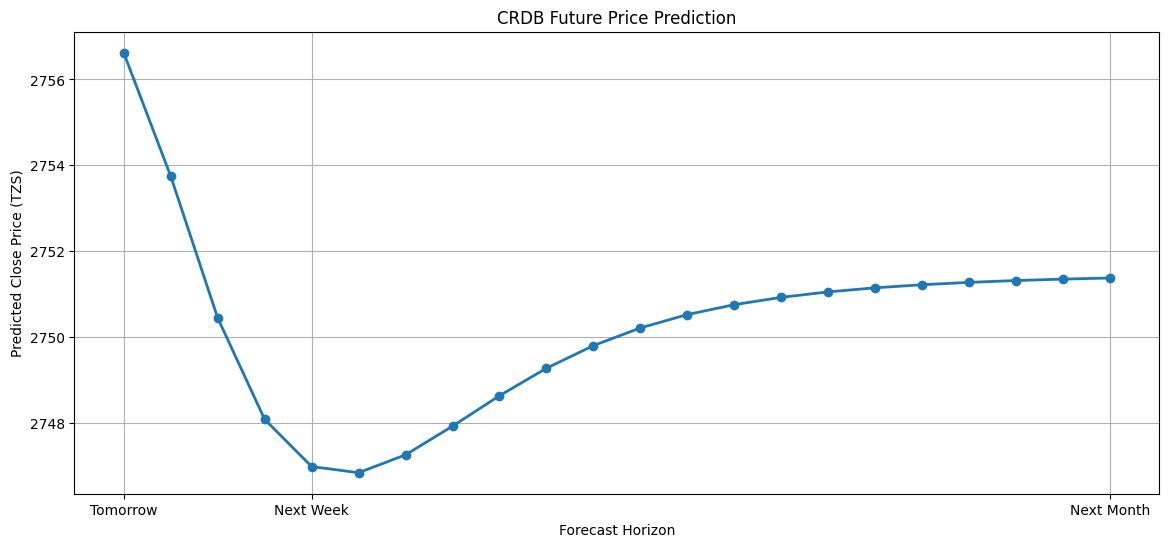


✅ FUTURE PREDICTION COMPLETED


In [28]:
# FUTURE PREDICTIONS
# =====================================================

future_sequence = scaled[-60:].copy()

future_predictions = []

for i in range(22):

    pred = model.predict(
        future_sequence.reshape(
            1,
            future_sequence.shape[0],
            future_sequence.shape[1]
        ),
        verbose=0
    )[0][0]

    future_predictions.append(pred)

    next_row = future_sequence[-1].copy()

    next_row[close_index] = pred

    future_sequence = np.vstack(
        (
            future_sequence[1:],
            next_row
        )
    )

future_predictions = np.array(future_predictions)

future_prices = inverse_close(future_predictions)

# =====================================================
# TODAY
# =====================================================

today_price = df["Close"].iloc[-1]

# =====================================================
# TOMORROW
# =====================================================

tomorrow_price = future_prices[0]

# =====================================================
# NEXT WEEK
# =====================================================

next_week_price = future_prices[4]

# =====================================================
# NEXT MONTH
# =====================================================

next_month_price = future_prices[-1]

print("\n")
print("="*50)
print("CRDB PRICE FORECAST")
print("="*50)

print(f"Today's Close       : {today_price:.2f} TZS")
print(f"Tomorrow Prediction : {tomorrow_price:.2f} TZS")
print(f"Next Week Prediction: {next_week_price:.2f} TZS")
print(f"Next Month Forecast : {next_month_price:.2f} TZS")

# =====================================================
# FUTURE GRAPH
# =====================================================

plt.figure(figsize=(14,6))

plt.plot(
    range(len(future_prices)),
    future_prices,
    marker="o",
    linewidth=2
)

plt.xticks(
    [0,4,21],
    [
        "Tomorrow",
        "Next Week",
        "Next Month"
    ]
)

plt.title("CRDB Future Price Prediction")
plt.xlabel("Forecast Horizon")
plt.ylabel("Predicted Close Price (TZS)")
plt.grid(True)

plt.show()

print("\n✅ FUTURE PREDICTION COMPLETED")